# AI Capstone Project Preparation - Midterm Project

## Import Libraries

In [11]:
from sklearn.model_selection import train_test_split  # Importing train_test_split from sklearn for splitting the data
from sklearn.linear_model import LogisticRegression  # Importing LogisticRegression from sklearn
from sklearn.metrics import confusion_matrix, classification_report # Importing evaluation metrics from sklearn
from sklearn.preprocessing import StandardScaler # Importing StandardScaler for feature scaling
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt  # Importing matplotlib for plotting
import numpy as np  # Importing numpy for numerical operations
import pandas as pd  # Importing pandas for data manipulation
import seaborn as sns  # Importing seaborn for advanced visualizations
import warnings  # Importing warnings to manage warning messages

# We'll ignore any warnings to keep our output clean.
warnings.filterwarnings('ignore')  # This will suppress any warning messages

## Load and Explore Data

Dataset shape: (30000, 44)

Class distribution:
CLASS
no     28254
yes     1746
Name: count, dtype: int64


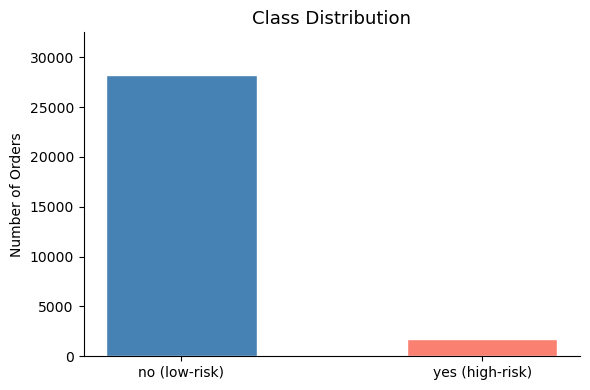


First few rows of the dataset:


,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,...,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,NaN,5.2006,...,no,no,no,8,yes,0,0.00,NaN,NaN,NaN
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,...,yes,no,no,13,yes,0,0.00,NaN,NaN,NaN
2,49923,no,yes,no,4/3/1972,yes,no,check,NaN,12.2007,...,no,no,no,3,yes,0,0.00,NaN,NaN,NaN
3,49924,no,no,yes,8/1/1966,yes,no,check,NaN,1.2007,...,no,no,no,11,no,4,75.72,5/12/2002,0.0,0.0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,...,no,no,no,16,yes,0,0.00,NaN,NaN,NaN


In [4]:
df = pd.read_csv("risk-train.txt", sep="\t", na_values="?", low_memory=False) # Load dataset and treat "?" as missing value
print(f"Dataset shape: {df.shape}")     # Print the number of rows and columns of dataset
print(f"\nClass distribution:")         
print(df["CLASS"].value_counts())       # Print the count of each class to see distribution of dataset

counts = df["CLASS"].value_counts()

# Plot the distribution of target = Class so we can visualize the imbalance
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["no (low-risk)", "yes (high-risk)"],
    counts[["no", "yes"]],
    color=["steelblue", "salmon"],
    edgecolor="white",
    width=0.5
)
ax.set_title("Class Distribution", fontsize=13)
ax.set_ylabel("Number of Orders")
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Print the first few rows of dataset
print("\nFirst few rows of the dataset:")
df.head()

---
## Data Preparation

### Understanding Missing Data

In [5]:
# Step 1: Understand the missing data -----------------------------------------------------------
missing = (df.isnull().mean().sort_values(ascending=False) * 100).round(1)
missing = missing[missing > 0]
print("Columns with missing values:")
print((missing.astype(str) + "%").to_string())

Columns with missing values:
ANUMMER_10      100.0%
ANUMMER_09      100.0%
ANUMMER_08       99.9%
ANUMMER_07       99.7%
ANUMMER_06       99.3%
ANUMMER_05       98.2%
ANUMMER_04       95.6%
ANUMMER_03       89.3%
ANUMMER_02       73.8%
Z_CARD_ART       62.2%
MAHN_AKT         52.9%
DATE_LORDER      52.9%
MAHN_HOECHST     52.9%
Z_LAST_NAME      49.4%
B_BIRTHDATE       9.8%
TIME_ORDER        0.1%


### Data Preprocessing

In [6]:
# Step 2: Drop unnecessary / high-missing columns ----------------------------------------------
# These columns have half or more missing values so they don't really add value
# ORDER_ID       : Row identifier and is not a feature
# ANUMMER_02–10  : Product codes most of which are missing (74–100%)
# Z_CARD_ART     : 62.2% missing
# MAHN_AKT       : 52.9% missing
# DATE_LORDER    : 52.9% missing
# MAHN_HOECHST   : 52.9% missing
# Z_LAST_NAME    : 49.4% missing --> Keep this since a name mismatch has a higher default rate than a match.
df.drop(columns=[
    "ORDER_ID",
    "ANUMMER_02", "ANUMMER_03", "ANUMMER_04",
    "ANUMMER_05", "ANUMMER_06", "ANUMMER_07", "ANUMMER_08",
    "ANUMMER_09", "ANUMMER_10",
    "Z_CARD_ART", "MAHN_AKT", "DATE_LORDER", "MAHN_HOECHST"
], inplace=True)
print(f"Shape after dropping columns:  {df.shape}")

# Step 3: Encode target and binary yes/no columns ----------------------------------------------
# All yes/no text columns are converted to 1/0 so the model can work with them numerically.
# CLASS is the target label (yes=1 high-risk, no=0 low-risk).
binary_cols = [
    "CLASS", "B_EMAIL", "B_TELEFON", "FLAG_LRIDENTISCH", "FLAG_NEWSLETTER",
    "CHK_LADR", "CHK_RADR", "CHK_KTO", "CHK_CARD", "CHK_COOKIE", "CHK_IP",
    "FAIL_LPLZ", "FAIL_LORT", "FAIL_LPLZORTMATCH", "FAIL_RPLZ", "FAIL_RORT",
    "FAIL_RPLZORTMATCH", "NEUKUNDE", "Z_LAST_NAME"
]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Step 4: Feature engineering -----------------------------------------------------------------
# Extract order hour from the time string so the model sees a numeric value (0–23)
df["TIME_ORDER"] = pd.to_datetime(df["TIME_ORDER"], format="%H:%M", errors="coerce").dt.hour

# Compute customer age from birth year — the raw date string is not useful to the model
df["B_BIRTHDATE"] = pd.to_datetime(df["B_BIRTHDATE"], errors="coerce")
df["AGE"] = 2026 - df["B_BIRTHDATE"].dt.year
df.drop(columns=["B_BIRTHDATE"], inplace=True) # Drop original date column now that AGE is created

# Step 5: Encode categorical variables --------------------------------------------------------
# WEEKDAY_ORDER and Z_METHODE are text categories converted to numeric dummy columns.
# drop_first=True removes one dummy per group to avoid multicollinearity.
df = pd.get_dummies(df, columns=["WEEKDAY_ORDER", "Z_METHODE"], drop_first=True)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# Step 6: Impute remaining missing values -----------------------------------------------------
# Fills any remaining NaNs with the median of each column.
# Median is used instead of mean as it is less affected by outliers.
df = df.fillna(df.median(numeric_only=True))

# Step 7: Verify Data Preprocessing -----------------------------------------------------------
print("Verify the Data Preprocessing")
print(f"Final shape:                {df.shape}")
print(f"Missing values remaining:   {df.isna().sum().sum()}")
print(f"Feature count:              {df.shape[1] - 1}")
df.columns

Shape after dropping columns:  (30000, 30)
Verify the Data Preprocessing
Final shape:                (30000, 37)
Missing values remaining:   0
Feature count:              36


Index(['CLASS', 'B_EMAIL', 'B_TELEFON', 'FLAG_LRIDENTISCH', 'FLAG_NEWSLETTER',
       'Z_CARD_VALID', 'Z_LAST_NAME', 'VALUE_ORDER', 'TIME_ORDER',
       'AMOUNT_ORDER', 'ANUMMER_01', 'CHK_LADR', 'CHK_RADR', 'CHK_KTO',
       'CHK_CARD', 'CHK_COOKIE', 'CHK_IP', 'FAIL_LPLZ', 'FAIL_LORT',
       'FAIL_LPLZORTMATCH', 'FAIL_RPLZ', 'FAIL_RORT', 'FAIL_RPLZORTMATCH',
       'SESSION_TIME', 'NEUKUNDE', 'AMOUNT_ORDER_PRE', 'VALUE_ORDER_PRE',
       'AGE', 'WEEKDAY_ORDER_Monday', 'WEEKDAY_ORDER_Saturday',
       'WEEKDAY_ORDER_Sunday', 'WEEKDAY_ORDER_Thursday',
       'WEEKDAY_ORDER_Tuesday', 'WEEKDAY_ORDER_Wednesday',
       'Z_METHODE_credit_card', 'Z_METHODE_debit_card',
       'Z_METHODE_debit_note'],
      dtype='object')

### Visualizations of Features vs High Risk

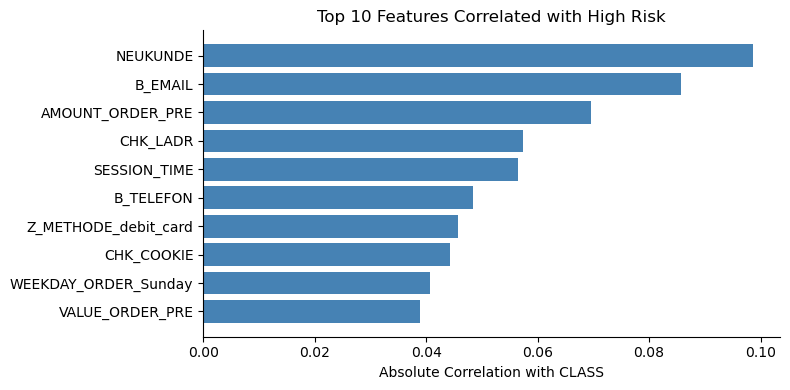

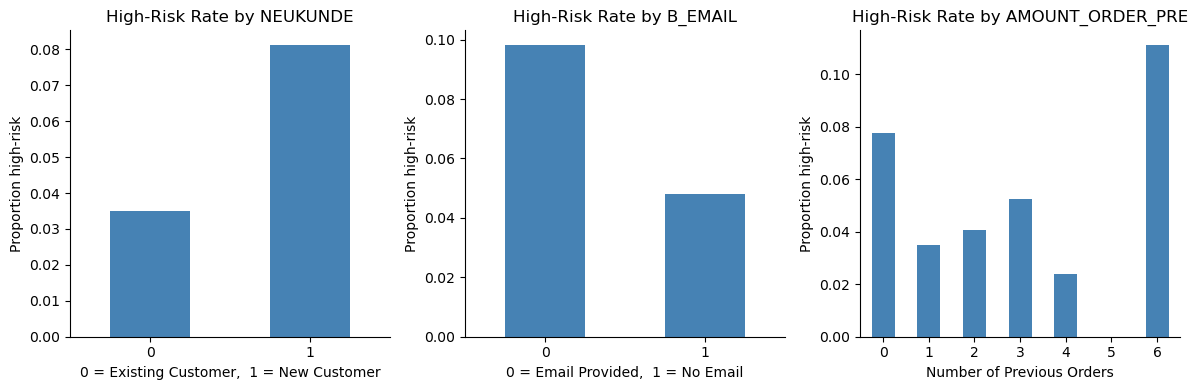

In [7]:
# Step 8: Visualization of Features ---------------------------------------------------------
# Compute the absolute correlation of each feature with the target CLASS
# Absolute value is used so negative correlations are ranked equally with positive ones
corr = df.corr()["CLASS"].drop("CLASS").abs().sort_values(ascending=False).head(10)

# Plot the top 10 features as a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(corr.index[::-1], corr.values[::-1], color="steelblue")
ax.set_xlabel("Absolute Correlation with CLASS")
ax.set_title("Top 10 Features Correlated with High Risk")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# Automatically select the 3 features most correlated with high-risk orders
top_3 = df.corr()["CLASS"].drop("CLASS").abs().sort_values(ascending=False).head(3).index

# Descriptive x-axis labels for each of the top 3 features
x_labels = {
    "NEUKUNDE" : "0 = Existing Customer,  1 = New Customer",
    "B_EMAIL" : "0 = Email Provided,  1 = No Email",
    "AMOUNT_ORDER_PRE" : "Number of Previous Orders"
}

# Plot one bar chart per feature showing the high-risk rate for each value
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, top_3):
    df.groupby(col)["CLASS"].mean().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"High-Risk Rate by {col}")
    ax.set_ylabel("Proportion high-risk")
    ax.set_xlabel(x_labels[col])
    ax.tick_params(rotation=0)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

---
## Train/Test Split and Performance Target

### Split Dataset

In [8]:
# Step 9: Separate features and target variable -------------------------------------------
X = df.drop(columns=["CLASS"])  # X contains all features the model will learn from
y = df["CLASS"]                 # y contains the target label (1 = high-risk, 0 = low-risk)

# Step 10: Stratified 80/20 train/test split ----------------------------------------------
# 80% of the data is used for training and 20% for testing.
# stratify=y ensures both sets maintain the same yes/no ratio as the original dataset,
# important given class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held out for testing
    random_state=42,    # Fixed seed for reproducibility
    stratify=y          # Preserve class proportions in both sets
)

print(f"Training set:  {X_train.shape[0]:,} samples")
print(f"Test set:      {X_test.shape[0]:,} samples")
print(f"\nClass proportions in original dataset:")
print(y.value_counts(normalize=True).round(4))
print(f"\nClass proportions in training set:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nClass proportions in test set:")
print(y_test.value_counts(normalize=True).round(4))

Training set:  24,000 samples
Test set:      6,000 samples

Class proportions in original dataset:
CLASS
0    0.9418
1    0.0582
Name: proportion, dtype: float64

Class proportions in training set:
CLASS
0    0.9418
1    0.0582
Name: proportion, dtype: float64

Class proportions in test set:
CLASS
0    0.9418
1    0.0582
Name: proportion, dtype: float64


### Train and Fit

In [9]:
# Step 11: Scale features -----------------------------------------------------------------
# StandardScaler transforms all features to the same scale so no single column dominates
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn the scale from training data and apply it
X_test_scaled  = scaler.transform(X_test)       # Apply that same scale to the test data

# Step 12: Train Logistic Regression ------------------------------------------------------
# class_weight="balanced" automatically increases the penalty for missing a high-risk order,
# proportional to how rare the yes class is (~6% of orders).
lr = LogisticRegression(
    class_weight="balanced",    # Compensates for the 94%/6% class imbalance
    max_iter=1000,              # Maximum iterations allowed for the solver to converge
    random_state=42             # Fixed seed for reproducibility
)

lr.fit(X_train_scaled, y_train)  # Train the model on scaled training data

# Step 13: Make predictions ---------------------------------------------------------------
y_pred = lr.predict(X_test_scaled)  # Predict class labels for the unseen test set

### Evaluation Metrics

                 precision    recall  f1-score   support

  no (low-risk)       0.97      0.65      0.78      5651
yes (high-risk)       0.11      0.72      0.19       349

       accuracy                           0.65      6000
      macro avg       0.54      0.69      0.49      6000
   weighted avg       0.92      0.65      0.74      6000



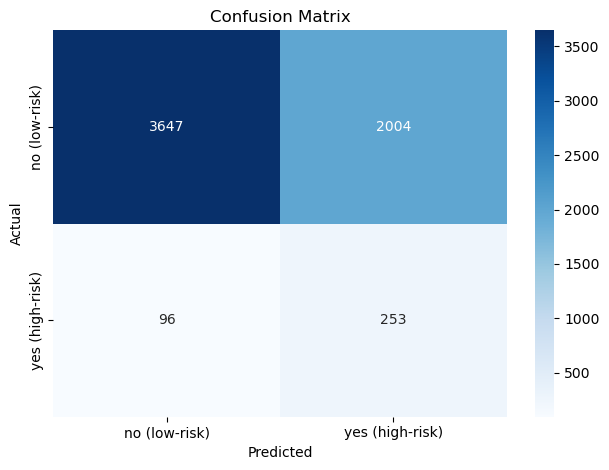

In [10]:
# Step 14: Evaluate the model -------------------------------------------------------------
# classification_report shows precision, recall, and F1-score for each class.
print(classification_report(y_test, y_pred, target_names=["no (low-risk)", "yes (high-risk)"]))

# Step 15: Confusion Matrix Heatmap ------------------------------------------------------
# A confusion matrix shows how many predictions were correct and where the model made mistakes.
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,           # Show the count numbers inside each cell
    fmt="d",              # Display counts as whole integers
    cmap="Blues",         # Blue colour scheme — darker = higher count
    xticklabels=["no (low-risk)", "yes (high-risk)"],
    yticklabels=["no (low-risk)", "yes (high-risk)"]
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")       # Row axis — what the true label was
plt.xlabel("Predicted")    # Column axis — what the model predicted
plt.tight_layout()
plt.show()

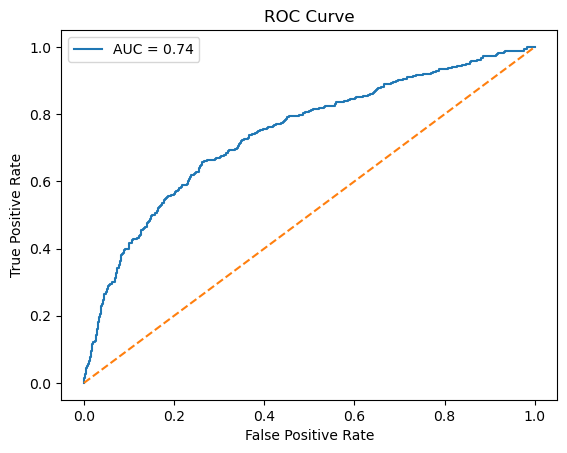

In [14]:
# Plotting the ROC curve
# Get predicted probabilities for the positive class (high-risk = 1)
y_prob = lr.predict_proba(X_test_scaled)[:, 1] # predict_proba gives probability of being high-risk

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob) #fpr means false positive rate and tpr means true positive rate i.e Recall/Sensitivity

# Compute AUC (Area Under Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # Random model baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()